In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
# ------------------------------
# 1.生成数据：y = x^2 + 噪声
# ------------------------------

np.random.seed(66)      #随机数种子

M=200  #样本数sample
x = np.linspace(-2, 2, M)        # 生成 200 个在 [-2, 2] 区间均匀分布的样本点,形状(M,)
y_true=x**2
noise=np.random.randn(M,)*0.05  #生成标准正态分布的随机数数组形状(M,)，均值 0，标准差 1
#乘以 0.05 后，标准差变为 0.05，均值仍为 0

y=y_true+noise

In [ ]:
# ------------------------------
# 2.网络结构，初始化
# ------------------------------
# 网络结构 1 -> 5 -> 5 -> 1
config=[1,5,5,1]        # 输入层1个神经元，两个隐藏层各5，输出层1
L=len(config)         #总层数L=4

# 初始化权重和偏置（列表，每个元素为 ndarray）
W = [None] * L        # 索引 0..L-1 
b = [None] * L        #  用None把W和b的第一个元素（索引0）占了
# 这其实是合理的，因为每个神经元的左边连着它的输入权重（类似突触），如果把输出也看作神经元，那它没有输入权重即None，只有输出x
#于是后面涉及权重层遍历的for都从1开始
for l in range(1, L):
    N_in,N_out= config[l-1],config[l] # 输入/输出神经元数目，输出层号就是神经元层号(l)

    # Xavier 初始化（适用于 tanh）
    scale = np.sqrt(2.0 / (N_in + N_out))

    W[l] = np.random.randn(N_out, N_in) * scale #随机初始化，W列表的每个元素是一个矩阵
    b[l] = np.zeros((N_out,))

In [ ]:
# ------------------------------
# 3. 激活函数及其导数
# ------------------------------
def tanh(z):
    return np.tanh(z)

def tanh_deriv(z):
    return 1 - np.tanh(z)**2

def identity(z):
    return z

def identity_deriv(z):
    return np.ones_like(z)
#恒等激活函数：f(z) = z，其导数=1，np.ones_like(z)返回一个和 z 形状完全相同的数组，所有元素都是 1
sigma = [identity,tanh, tanh, identity]
sigma_deriv = [identity_deriv ,tanh_deriv, tanh_deriv, identity_deriv]

eta=0.01  #学习率
epochs = 3000  #梯度下降更新次数
#每隔 400 个 epoch（训练轮次）打印一次当前的损失值
print_interval = 500
# 存储 loss 用于绘图
loss_history = []

In [24]:
# ------------------------------
# 4. 训练：反向传播 + 批量梯度下降
# ------------------------------
for epoch in range(epochs):
    total_loss=0.0
    
    dlossdW_sum = [None] + [np.zeros_like(W[l]) for l in range(1, L)]  #批量梯度下降要计算每个样本算出梯度的和，再求平均梯度来更新
    dlossdb_sum = [None] + [np.zeros_like(b[l]) for l in range(1, L)]
    for s in range(M):  #遍历样本
        xs=x[s] 
        ys=y[s]

        #前向传播
        z=[None]*L; a=[None]*L
        z[0]=np.array([xs]); a[0]=np.array([xs])  #输入层，一个[]只有一个索引

        for l in range(1,L):
            z[l]=np.einsum('ij,j->i',W[l],a[l-1])+b[l] #形状(N_out,)
            a[l]=sigma[l](z[l])
        
        ys_pred=a[-1][0] #标量
        loss = 0.5 * (ys - ys_pred)**2
        total_loss += loss

        #反向传播
        delta=[None]*L #误差项
        #输出层dL/da_i=-(y_i-a^(L)_i) 但这里i只有1个取值
        dlossdaL=-(ys - ys_pred)*np.ones_like(a[-1]) #标量转为np数组，形状(1,)
        delta[-1]=dlossdaL*identity_deriv(z[-1])  #(1,)*(1,)

        for l in range(L-1,0,-1):  #从L-1=3（最后一个）开始遍历，每次-1，直到0(不包含)，遍历l=3,2,1，三个权重,（w0全是None）

            dlossdWl=np.einsum('i,j->ij',delta[l],a[l-1])#dloss/dW0=None

            dlossdbl=delta[l] #dloss/db0=None            
            if l>1:
                temp=np.einsum('k,ki->i',delta[l],W[l])
                delta[l-1]=temp*sigma_deriv[l-1](z[l-1])
            
            dlossdW_sum[l]+=dlossdWl
            dlossdb_sum[l]+=dlossdbl
    
    #更新参数(样本平均梯度)
    for l in range(1,L):
        W[l]-=eta*(dlossdW_sum[l]/M);  b[l]-=eta*(dlossdb_sum[l]/M)

    avg_loss = total_loss / M

    loss_history.append(avg_loss)
    if (epoch+1) % print_interval == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

Epoch 500/3000, Loss: 0.350089
Epoch 1000/3000, Loss: 0.061075
Epoch 1500/3000, Loss: 0.030159
Epoch 2000/3000, Loss: 0.018740
Epoch 2500/3000, Loss: 0.013004
Epoch 3000/3000, Loss: 0.009660


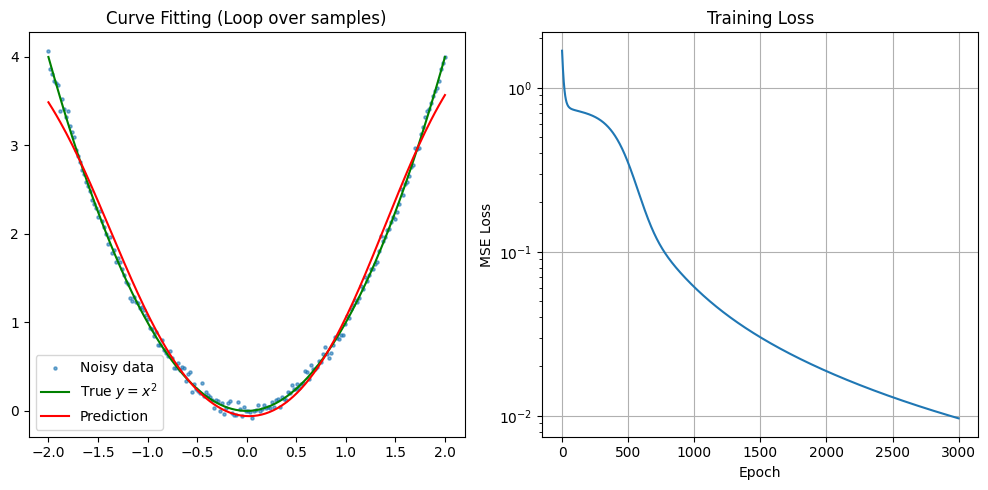

In [25]:
# 预测并画图
x_plot = np.linspace(-2, 2, 200)
y_plot = []
for xi in x_plot:
    a = np.array([xi])
    for l in range(1,L):
        z = np.einsum('ij,j->i', W[l], a) + b[l]
        a = sigma[l](z)
    y_plot.append(a[0])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.scatter(x, y, s=5, alpha=0.6, label='Noisy data')
plt.plot(x_plot, x_plot**2, 'g-', label='True $y=x^2$')
plt.plot(x_plot, y_plot, 'r-', label='Prediction')
plt.legend()
plt.title('Curve Fitting (Loop over samples)')

plt.subplot(1,2,2)
plt.plot(loss_history)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.grid(True)
plt.tight_layout()
plt.show()